<a href="https://colab.research.google.com/github/regisoliveiragx-rgb/Fonte-de-informa-o-e-banco-de-dados/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongeorge/beer-consumption-sao-paulo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'beer-consumption-sao-paulo' dataset.
Path to dataset files: /kaggle/input/beer-consumption-sao-paulo


In [5]:
import pandas as pd
import os

# The 'path' variable from the previous cell contains the directory where the dataset was downloaded.
# Let's inspect the contents of this directory to find the CSV file.
# The dataset name is 'beer-consumption-sao-paulo', so a CSV file related to beer consumption is expected.

# List contents of the downloaded directory
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

# Corrected filename based on the output above
data_file = os.path.join(path, 'Consumo_cerveja.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_file)

# Display the first few rows of the DataFrame and its information
print("\nDataset loaded successfully!")
print("DataFrame head:")
print(df.head(10))
print("\nDataFrame info:")
df.info()

Contents of /kaggle/input/beer-consumption-sao-paulo:
/kaggle/input/beer-consumption-sao-paulo/Consumo_cerveja.csv

Dataset loaded successfully!
DataFrame head:
         Data Temperatura Media (C) Temperatura Minima (C)  \
0  2015-01-01                  27,3                   23,9   
1  2015-01-02                 27,02                   24,5   
2  2015-01-03                 24,82                   22,4   
3  2015-01-04                 23,98                   21,5   
4  2015-01-05                 23,82                     21   
5  2015-01-06                 23,78                   20,1   
6  2015-01-07                    24                   19,5   
7  2015-01-08                  24,9                   19,5   
8  2015-01-09                  28,2                   21,9   
9  2015-01-10                 26,76                   22,1   

  Temperatura Maxima (C) Precipitacao (mm)  Final de Semana  \
0                   32,5                 0              0.0   
1                   33,5      

## Data Cleaning and Preprocessing

Based on the `df.info()` output, several columns ('Temperatura Media (C)', 'Temperatura Minima (C)', 'Temperatura Maxima (C)', 'Precipitacao (mm)') are of `object` type but represent numerical values. This suggests issues like comma decimal separators. The 'Data' column should also be converted to a datetime format. Additionally, there are many missing values to address.

In [6]:
# Rename columns for easier access
df.columns = [
    'Date',
    'Mean_Temperature_C',
    'Min_Temperature_C',
    'Max_Temperature_C',
    'Precipitation_mm',
    'Weekend',
    'Beer_Consumption_liters'
]

# Convert 'object' columns to numeric by replacing ',' with '.'
for col in ['Mean_Temperature_C', 'Min_Temperature_C', 'Max_Temperature_C', 'Precipitation_mm']:
    df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Drop rows with any missing values. From df.info(), it seems only 365 rows have complete data.
df_cleaned = df.dropna().reset_index(drop=True)

# Display cleaned DataFrame info and head to verify changes
print("\nCleaned DataFrame Info:")
df_cleaned.info()
print("\nCleaned DataFrame Head:")
print(df_cleaned.head())


Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     365 non-null    datetime64[ns]
 1   Mean_Temperature_C       365 non-null    float64       
 2   Min_Temperature_C        365 non-null    float64       
 3   Max_Temperature_C        365 non-null    float64       
 4   Precipitation_mm         365 non-null    float64       
 5   Weekend                  365 non-null    float64       
 6   Beer_Consumption_liters  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB

Cleaned DataFrame Head:
        Date  Mean_Temperature_C  Min_Temperature_C  Max_Temperature_C  \
0 2015-01-01               27.30               23.9               32.5   
1 2015-01-02               27.02               24.5               33.5   
2 2015-01-03   

## Linear Regression Model

Now that the data is cleaned and properly formatted, we can proceed with linear regression. We will use the temperature, precipitation, and weekend features to predict beer consumption.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df_cleaned[['Mean_Temperature_C', 'Min_Temperature_C', 'Max_Temperature_C', 'Precipitation_mm', 'Weekend']]
y = df_cleaned['Beer_Consumption_liters']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_:.2f}")


# Display actual vs predicted values for a sample
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nSample of Actual vs Predicted Beer Consumption:")
display(results_df.head())

Mean Squared Error: 5.70
R-squared: 0.74
Model Coefficients: [ 0.09651351 -0.06281587  0.63068847 -0.04341428  5.14718829]
Model Intercept: 6.42

Sample of Actual vs Predicted Beer Consumption:


,Actual,Predicted
193,25.640,25.600080
33,31.655,27.068774
15,29.938,28.112757
309,20.575,21.575376
57,26.241,27.293477


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir as variáveis X (recurso) e y (alvo)
X = df[['Temperature']].values  # Usar .values para obter um array numpy
y = df['Ice Cream Profits'].values

# Criar e treinar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Imprimir os coeficientes e o intercepto do modelo
print(f"Coeficiente (inclinação): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")
print(f"(model.coef_[0]:.2f)x+{model.intercept_:.2f}")

Coeficiente (inclinação): 1.19
Intercepto: -33.70
(model.coef_[0]:.2f)x+-33.70


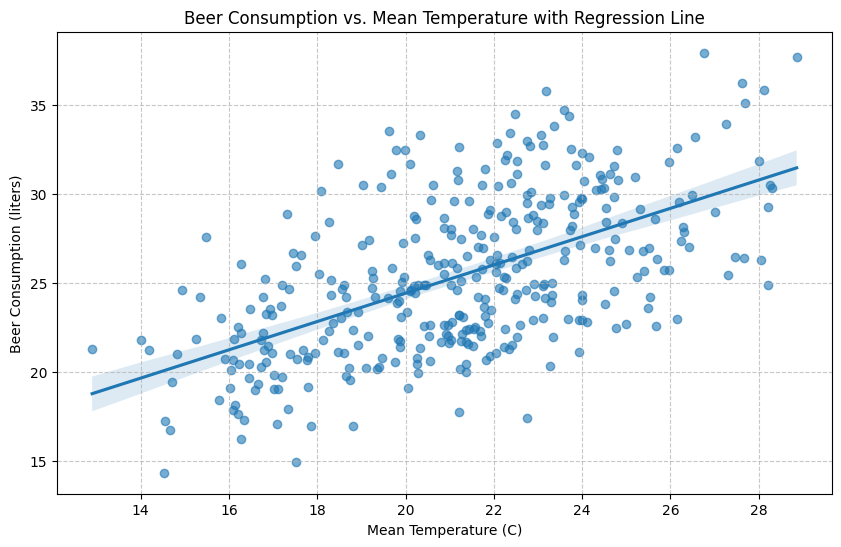

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='Mean_Temperature_C', y='Beer_Consumption_liters', data=df_cleaned, scatter_kws={'alpha':0.6})
plt.title('Beer Consumption vs. Mean Temperature with Regression Line')
plt.xlabel('Mean Temperature (C)')
plt.ylabel('Beer Consumption (liters)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()